# 08 — Peeking and the Sequential Testing Risk
**Prerequisites:** `07_multiple_testing.ipynb`; statistics_course/06_hypothesis_testing.ipynb.
**Connects to:** **experimental_design_course/06_sequential_testing.ipynb** for the full SPRT /
group-sequential / always-valid math — this notebook only demonstrates *why* the problem exists
and summarizes the practical fixes, it does not re-derive them.

## Narrative thread
```
The peeking problem -> simulation of false-positive inflation under repeated looks
   -> always-valid p-values / mSPRT (pointer) -> practical stopping rules used in industry
```

## The peeking problem

A fixed-horizon hypothesis test (a plain t-test or z-test) controls the Type I error rate **only
if you look at the data exactly once**, at the pre-planned sample size. In practice, product and
growth teams check dashboards *continuously* while an experiment runs and are tempted to stop as
soon as $p<0.05$ appears. This is "peeking," and it inflates the **true** false-positive rate far
above the nominal $\alpha$, because you are implicitly running many correlated tests (one at each
look) and stopping at the first favorable one — a special, particularly dangerous case of the
multiple-testing problem from `07_multiple_testing.ipynb`, except the tests are on the *same*
accumulating data over time rather than independent metrics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

In [2]:
# ── Simulate the inflation: many experiments, ALL with zero true effect, checked repeatedly ──
np.random.seed(99)
n_simulations = 3000
max_n_per_arm = 2000
check_points = np.arange(100, max_n_per_arm + 1, 100)   # look every 100 users/arm

def run_one_experiment_with_peeking(alpha=0.05):
    control = np.random.normal(0, 1, max_n_per_arm)
    treatment = np.random.normal(0, 1, max_n_per_arm)   # true null: identical distributions
    for n in check_points:
        p = stats.ttest_ind(treatment[:n], control[:n]).pvalue
        if p < alpha:
            return True   # "stopped early, declared significant" -- a false positive since truth is null
    return False   # never crossed the threshold across all looks

def run_one_experiment_fixed_horizon(alpha=0.05):
    control = np.random.normal(0, 1, max_n_per_arm)
    treatment = np.random.normal(0, 1, max_n_per_arm)
    p = stats.ttest_ind(treatment, control).pvalue
    return p < alpha

peeking_false_positives = np.mean([run_one_experiment_with_peeking() for _ in range(n_simulations)])
fixed_false_positives = np.mean([run_one_experiment_fixed_horizon() for _ in range(n_simulations)])

print(f"Nominal alpha: 0.05")
print(f"Empirical false-positive rate, FIXED horizon (look once at the end): {fixed_false_positives:.3f}")
print(f"Empirical false-positive rate, PEEKING (stop at first p<0.05 across {len(check_points)} looks): {peeking_false_positives:.3f}")
print(f"\nInflation factor: {peeking_false_positives / fixed_false_positives:.1f}x nominal rate")

Nominal alpha: 0.05
Empirical false-positive rate, FIXED horizon (look once at the end): 0.052
Empirical false-positive rate, PEEKING (stop at first p<0.05 across 20 looks): 0.247

Inflation factor: 4.7x nominal rate


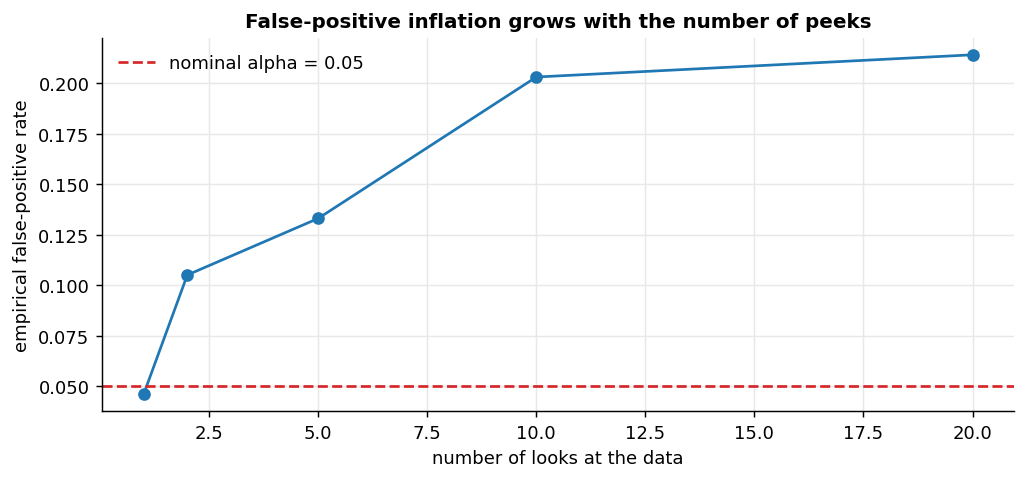

In [3]:
# ── Visualize how the false-positive rate grows with the number of looks ──
n_looks_range = [1, 2, 5, 10, 20]
inflation = []
for n_looks in n_looks_range:
    checks = np.linspace(200, max_n_per_arm, n_looks).astype(int)
    def run_with_k_looks():
        control = np.random.normal(0, 1, max_n_per_arm)
        treatment = np.random.normal(0, 1, max_n_per_arm)
        for n in checks:
            if stats.ttest_ind(treatment[:n], control[:n]).pvalue < 0.05:
                return True
        return False
    fp_rate = np.mean([run_with_k_looks() for _ in range(1000)])
    inflation.append(fp_rate)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(n_looks_range, inflation, 'o-', color='#1f77b4')
ax.axhline(0.05, color='#d62728', ls='--', label='nominal alpha = 0.05')
ax.set_xlabel('number of looks at the data'); ax.set_ylabel('empirical false-positive rate')
ax.set_title('False-positive inflation grows with the number of peeks')
ax.legend(); plt.tight_layout(); plt.show()

## Always-valid inference (pointer, not derived here)

The fix used by modern experimentation platforms is **always-valid p-values**, built from
**mixture sequential probability ratio tests (mSPRT)** or confidence sequences, which remain
valid *no matter when or how often you look* — you can check the dashboard every hour and stop
the instant the always-valid bound crosses the threshold, with the Type I error guarantee intact
by construction. This is the approach of **Johari, Koomen, Pekelis & Walsh (2017)**, "Peeking at
A/B Tests," used in production A/B testing platforms (e.g. Optimizely's Stats Engine).

The full mathematics — the SPRT likelihood ratio, Wald's boundaries, group-sequential
alpha-spending (O'Brien-Fleming, Lan-DeMets), and the mSPRT construction of always-valid
p-values — is developed in **`experimental_design_course/06_sequential_testing.ipynb`**; we do
not re-derive it here. The takeaway to carry from this notebook: **if you might look more than
once, you need a sequential method, not a fixed-horizon t-test evaluated repeatedly.**

## Practical stopping rules used in industry

| Approach | How it works | Trade-off |
|---|---|---|
| **Fixed horizon, no peeking** | Pre-register sample size, look once | Simplest, but requires discipline / platform enforcement (hide results until then) |
| **Always-valid p-values (mSPRT)** | Continuously valid bound; stop any time it crosses the threshold | Requires more sophisticated tooling; slightly wider intervals early on |
| **Group sequential design** | Pre-specify a *small number* of analysis points with an alpha-spending function | A middle ground; common in fixed cadence "weekly review" processes |
| **Minimum-runtime guardrail** | Enforce a minimum experiment duration (e.g. 1-2 full business cycles) regardless of the metric's readout | Cheap, low-tech mitigation; does not fully solve peeking but limits its damage |

## Key takeaways

| Concept | Statement |
|---|---|
| Peeking | Repeated fixed-horizon tests inflate the true false-positive rate far above nominal alpha |
| Cause | Stopping at the first significant look is an implicit multiple-comparisons problem over time |
| Fix | Always-valid p-values / mSPRT (Johari et al. 2017) or group-sequential designs; full math in experimental_design_course/06 |

## References

- Johari, R., Koomen, P., Pekelis, L., & Walsh, D. (2017). Peeking at A/B Tests: Why It Matters, and What to Do About It. *KDD 2017*.
- Kohavi, R., Tang, D., & Xu, Y. (2020). *Trustworthy Online Controlled Experiments*, Ch. 19 (peeking and sequential testing in practice).
- See `experimental_design_course/06_sequential_testing.ipynb` for SPRT, O'Brien-Fleming boundaries, and alpha-spending derivations.
